<a href="https://colab.research.google.com/github/MMujtabaX/Clustering/blob/main/Clustering_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 Clustering: K-Means · Hierarchical · DBSCAN
### AtomCamp MLOps Series

> **Unsupervised learning — no labels, find hidden structure in data.**

---
**What you'll learn:**
1. What clustering is and when to use it
2. K-Means — algorithm, elbow method, limitations
3. Hierarchical Clustering — dendrogram and linkage methods
4. DBSCAN — density-based, handles noise and arbitrary shapes
5. Comparing all three on different dataset shapes


## 0. Imports & Setup


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import (
    make_blobs, make_moons, make_circles,
    load_iris, make_classification
)
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, davies_bouldin_score
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)
print('All libraries loaded!')


All libraries loaded!


---
## 1. What is Clustering?

Clustering groups data points so that:
- Points **within** a cluster are **similar** to each other
- Points **across** clusters are **different** from each other

**No labels needed** — the algorithm finds structure on its own.

| Type | Algorithm | Key idea |
|------|-----------|----------|
| Partitional | K-Means | Minimize distance to centroids |
| Hierarchical | Agglomerative | Build a tree of merges |
| Density-based | DBSCAN | Dense regions = clusters |


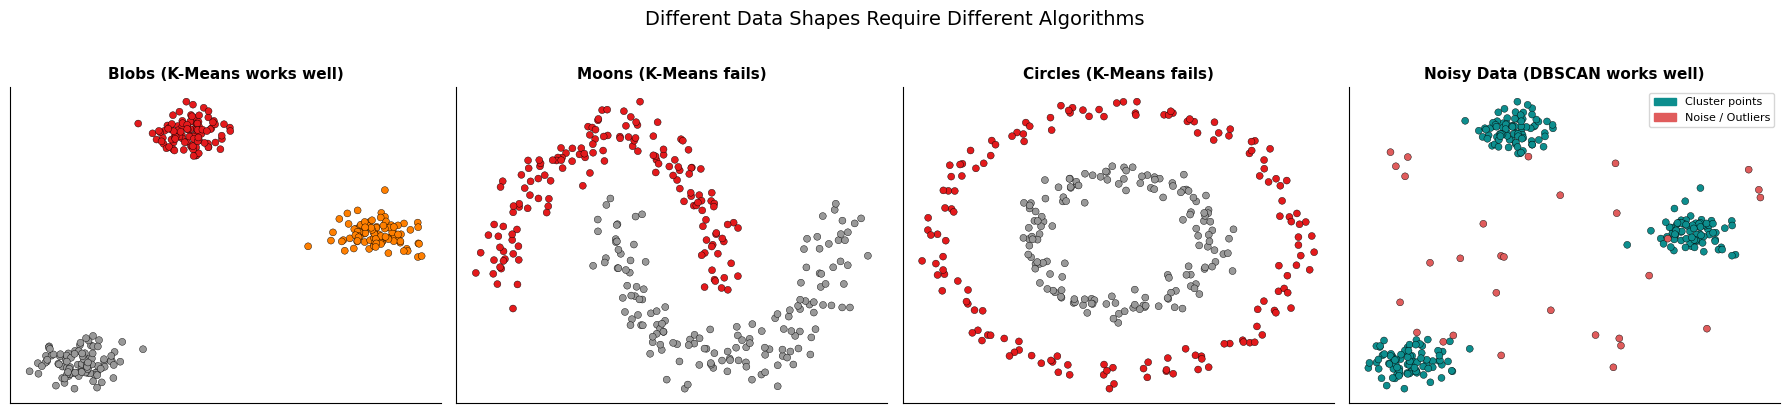

In [ ]:
# Visualize different cluster shapes — this motivates WHY we need different algorithms
datasets = [
    (make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),
     'Blobs (K-Means works well)'),
    (make_moons(n_samples=300, noise=0.1, random_state=42),
     'Moons (K-Means fails)'),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
     'Circles (K-Means fails)'),
]

# Add noisy blobs for DBSCAN demo
X_noisy, y_noisy = make_blobs(n_samples=250, centers=3, cluster_std=0.8, random_state=42)
noise = np.random.uniform(-8, 8, (30, 2))
X_noisy = np.vstack([X_noisy, noise])
y_noisy = np.hstack([y_noisy, [-1]*30])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, ((X, y), title) in zip(axes[:3], datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', s=25, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

colors_noisy = ['#0D8E8E' if l >= 0 else '#E05C5C' for l in y_noisy]
axes[3].scatter(X_noisy[:, 0], X_noisy[:, 1], c=colors_noisy, s=25, edgecolors='k', linewidths=0.3)
axes[3].set_title('Noisy Data (DBSCAN works well)', fontsize=11, fontweight='bold')
axes[3].set_xticks([]); axes[3].set_yticks([])
red_patch   = mpatches.Patch(color='#E05C5C', label='Noise / Outliers')
green_patch = mpatches.Patch(color='#0D8E8E', label='Cluster points')
axes[3].legend(handles=[green_patch, red_patch], fontsize=8)

plt.suptitle('Different Data Shapes Require Different Algorithms', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 2. K-Means Clustering

**Algorithm:**
1. Randomly initialize K centroids
2. Assign each point to the **nearest centroid** (Euclidean distance)
3. Recompute each centroid = **mean** of assigned points
4. Repeat 2–3 until centroids stop moving

**Objective (minimize WCSS):**
$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$
where $\mu_k$ is the centroid of cluster $k$.


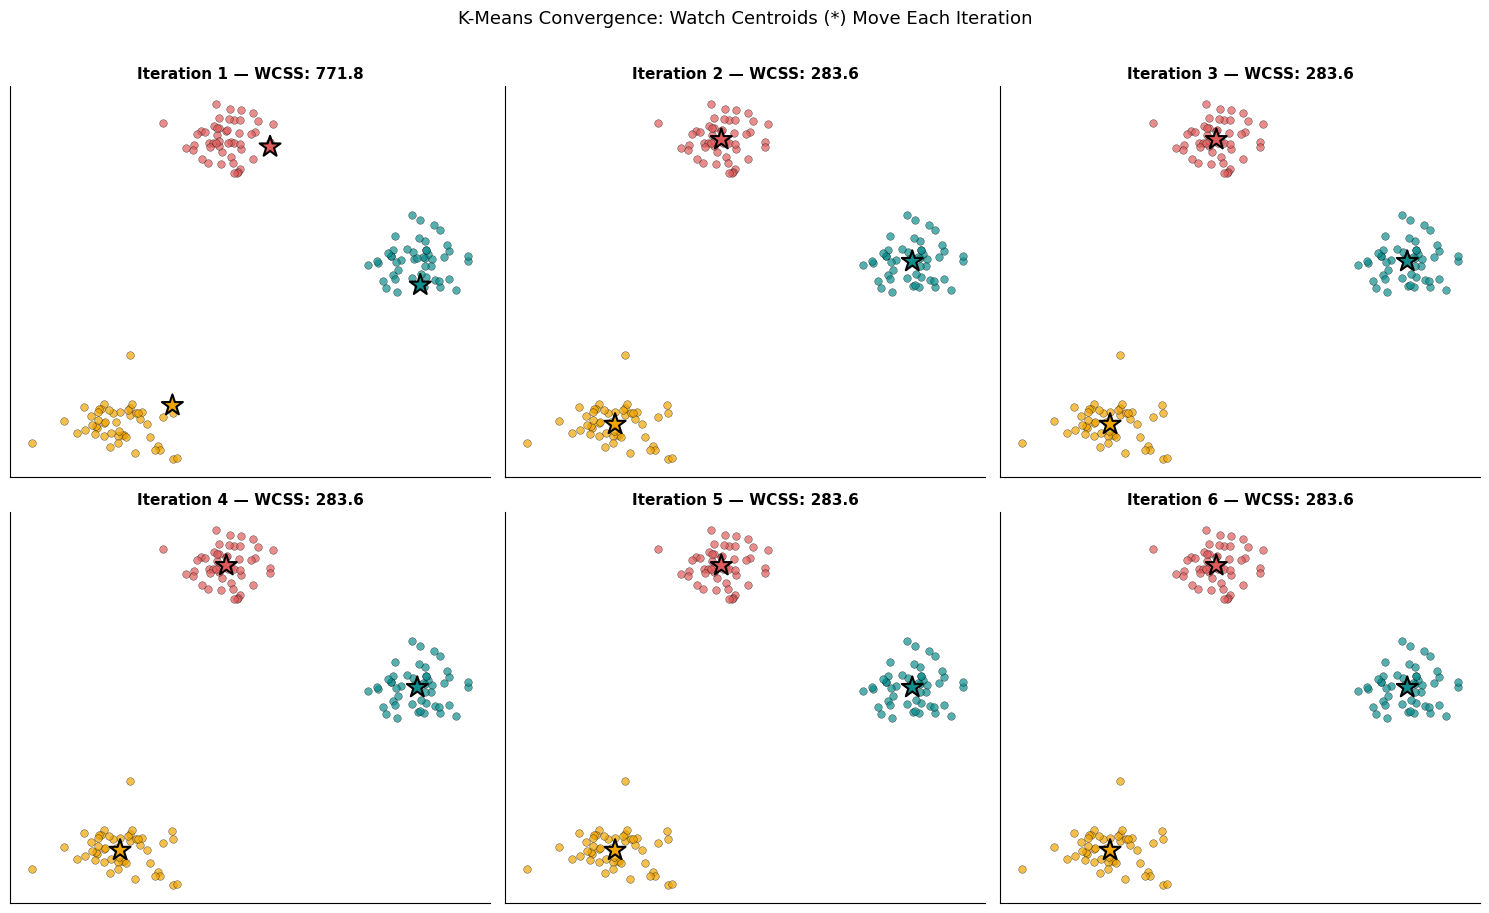

In [ ]:
# Step-by-step K-Means visualization
X_blob, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

COLORS = ['#0D8E8E', '#E05C5C', '#F0A500', '#6D3FA0']
K = 3

# Init centroids randomly
np.random.seed(10)
centroids = X_blob[np.random.choice(len(X_blob), K, replace=False)]

for step in range(6):
    ax = axes[step]

    # Assign
    dists = cdist(X_blob, centroids)
    labels = np.argmin(dists, axis=1)

    # Plot points
    for k in range(K):
        mask = labels == k
        ax.scatter(X_blob[mask, 0], X_blob[mask, 1],
                   color=COLORS[k], s=30, alpha=0.7, edgecolors='k', linewidths=0.3)
    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1],
               color=[COLORS[k] for k in range(K)],
               s=250, marker='*', edgecolors='black', linewidths=1.5,
               zorder=5, label='Centroids')

    wcss = sum(np.sum((X_blob[labels==k] - centroids[k])**2) for k in range(K))
    ax.set_title(f'Iteration {step+1} — WCSS: {wcss:.1f}', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    # Update centroids
    new_centroids = np.array([X_blob[labels==k].mean(axis=0) for k in range(K)])

    # Draw centroid movement arrows
    if step > 0:
        for old_c, new_c in zip(centroids, new_centroids):
            ax.annotate('', xy=new_c, xytext=old_c,
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    centroids = new_centroids

plt.suptitle('K-Means Convergence: Watch Centroids (*) Move Each Iteration', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


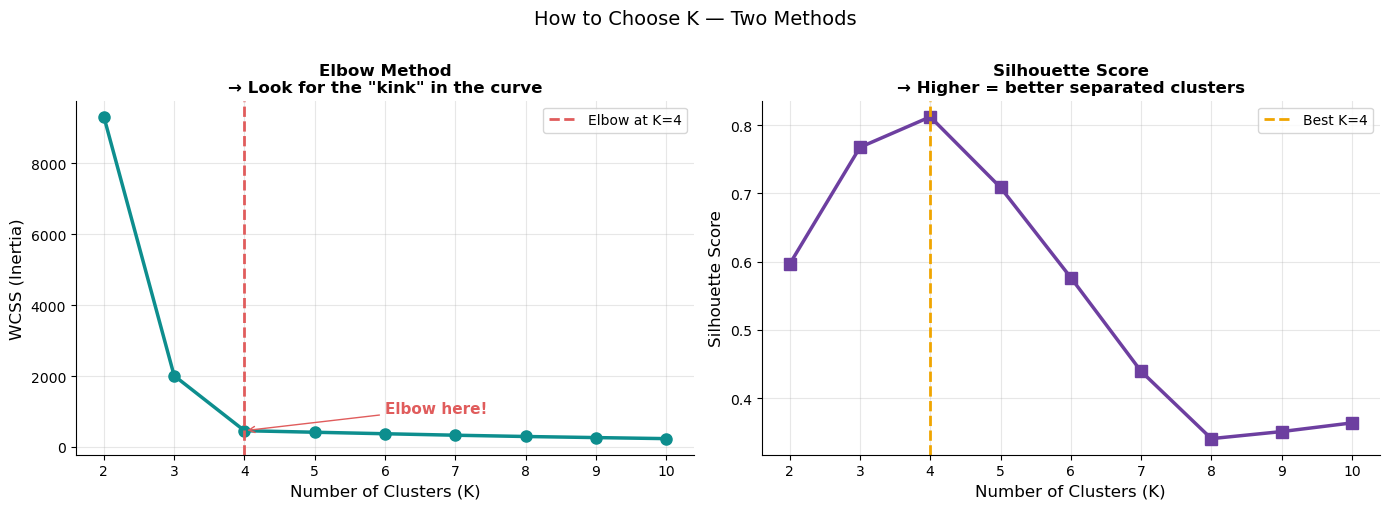

Elbow suggests K ≈ 4  |  Silhouette best K = 4
True number of clusters in data = 4 ✓


In [ ]:
# Elbow Method — choosing the right K
X_blob, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)

wcss_vals = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blob)
    wcss_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_blob, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, wcss_vals, 'o-', color='#0D8E8E', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='#E05C5C', linestyle='--', linewidth=2, label='Elbow at K=4')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method\n→ Look for the "kink" in the curve', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
# Annotate elbow
axes[0].annotate('Elbow here!', xy=(4, wcss_vals[2]),
                  xytext=(6, wcss_vals[2]+500),
                  arrowprops=dict(arrowstyle='->', color='#E05C5C'),
                  fontsize=11, color='#E05C5C', fontweight='bold')

# Silhouette score
axes[1].plot(k_range, silhouette_vals, 's-', color='#6D3FA0', linewidth=2.5, markersize=8)
best_k = list(k_range)[np.argmax(silhouette_vals)]
axes[1].axvline(x=best_k, color='#F0A500', linestyle='--', linewidth=2,
                label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score\n→ Higher = better separated clusters', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('How to Choose K — Two Methods', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Elbow suggests K ≈ 4  |  Silhouette best K = {best_k}')
print('True number of clusters in data = 4 ✓')


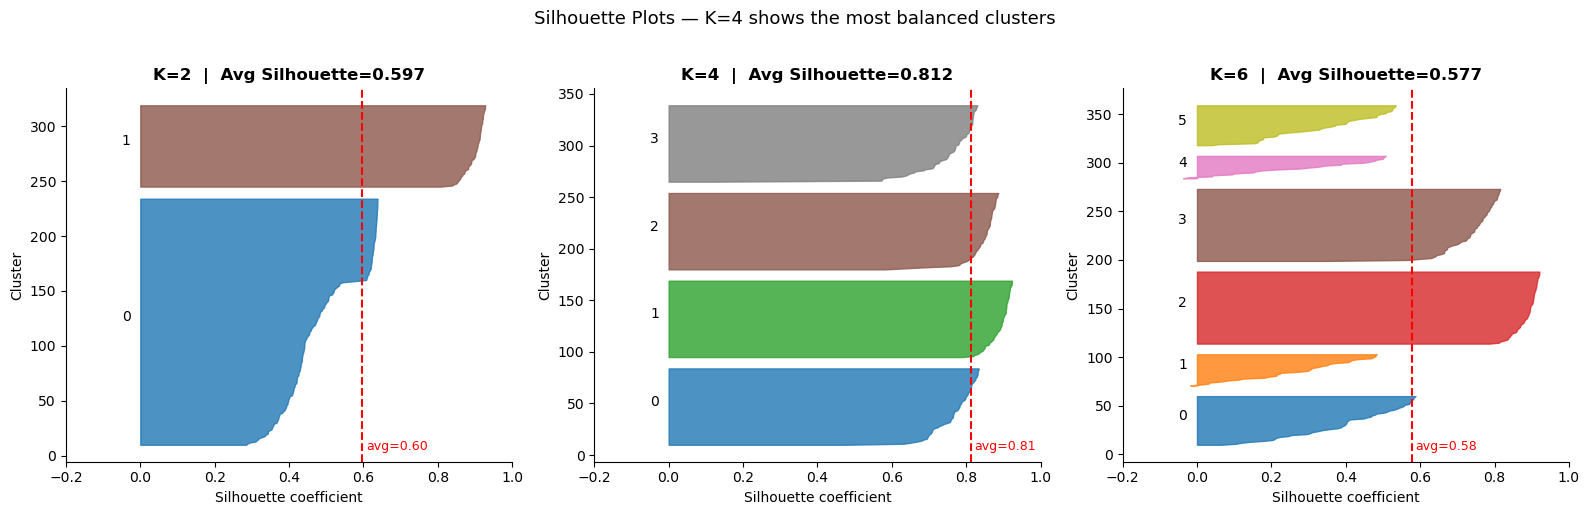

In [ ]:
# Silhouette plot — detailed view of cluster quality
from matplotlib import cm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_idx, k in enumerate([2, 4, 6]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blob)
    sil_vals = silhouette_samples(X_blob, labels)
    sil_avg  = silhouette_score(X_blob, labels)

    ax = axes[ax_idx]
    y_lower = 10
    cmap = cm.get_cmap('tab10')

    for i in range(k):
        ith_sil = np.sort(sil_vals[labels == i])
        size = len(ith_sil)
        y_upper = y_lower + size
        color = cmap(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                          facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + size/2, str(i), fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'K={k}  |  Avg Silhouette={sil_avg:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster')
    ax.set_xlim([-0.2, 1])
    ax.text(sil_avg + 0.01, 5, f'avg={sil_avg:.2f}', color='red', fontsize=9)

plt.suptitle('Silhouette Plots — K=4 shows the most balanced clusters', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# K-Means limitations — fails on non-spherical shapes
datasets_shapes = [
    (make_moons(n_samples=300, noise=0.05, random_state=42),   'Moons', 2),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42), 'Circles', 2),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ((X_s, y_true), name, k) in zip(axes, datasets_shapes):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    sil = silhouette_score(X_s, labels)
    ari = adjusted_rand_score(y_true, labels)

    ax.scatter(X_s[:, 0], X_s[:, 1], c=labels, cmap='RdYlBu',
               s=30, edgecolors='k', linewidths=0.3)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               color='black', s=200, marker='X', zorder=5, label='Centroids')
    ax.set_title(f'K-Means on {name}\nSilhouette={sil:.2f}  |  ARI={ari:.2f} (1=perfect)',
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('K-Means FAILS on non-spherical shapes (use DBSCAN instead)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('Low ARI score = K-Means got the clustering wrong vs true labels')


---
## 3. Hierarchical Clustering

**Key idea:** Build a tree of merges. No need to specify K upfront — choose K by cutting the tree.

**Algorithm (Agglomerative / bottom-up):**
1. Start: each point is its own cluster (N clusters)
2. Find the 2 closest clusters and **merge** them
3. Recompute distances
4. Repeat until 1 cluster remains
5. Cut the dendrogram at any height to get K clusters

### Linkage Methods
| Linkage | Distance between clusters | When to use |
|---------|--------------------------|-------------|
| Single | Min distance of any pair | Non-spherical shapes |
| Complete | Max distance of any pair | Compact, equal-size clusters |
| Average | Mean of all pairs | Balanced, general use |
| Ward | Minimizes total within-cluster variance | **Default — best for most cases** |


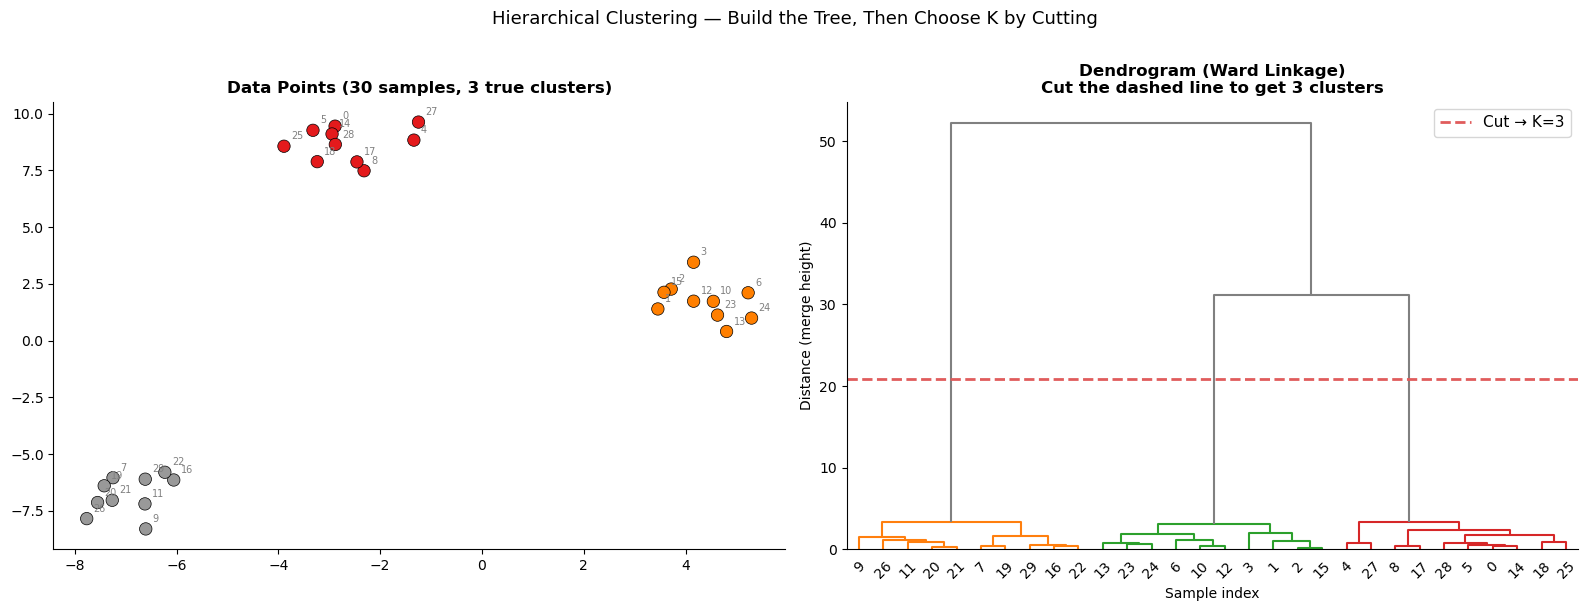

In [ ]:
# Dendrogram visualization
X_hier, y_hier = make_blobs(n_samples=30, centers=3, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(X_hier[:, 0], X_hier[:, 1], c=y_hier, cmap='Set1',
                s=80, edgecolors='k', linewidths=0.5)
for i, (x, y) in enumerate(X_hier):
    axes[0].annotate(str(i), (x, y), textcoords='offset points',
                      xytext=(5, 5), fontsize=7, color='gray')
axes[0].set_title('Data Points (30 samples, 3 true clusters)', fontsize=12, fontweight='bold')

# Dendrogram
Z = linkage(X_hier, method='ward')
dn = dendrogram(Z, ax=axes[1], above_threshold_color='gray',
                color_threshold=0.4 * max(Z[:, 2]))
# Draw cut line
cut_height = 0.4 * max(Z[:, 2])
axes[1].axhline(y=cut_height, color='#E05C5C', linestyle='--', linewidth=2, label=f'Cut → K=3')
axes[1].set_title('Dendrogram (Ward Linkage)\nCut the dashed line to get 3 clusters', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Distance (merge height)')
axes[1].legend(fontsize=11)

plt.suptitle('Hierarchical Clustering — Build the Tree, Then Choose K by Cutting', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


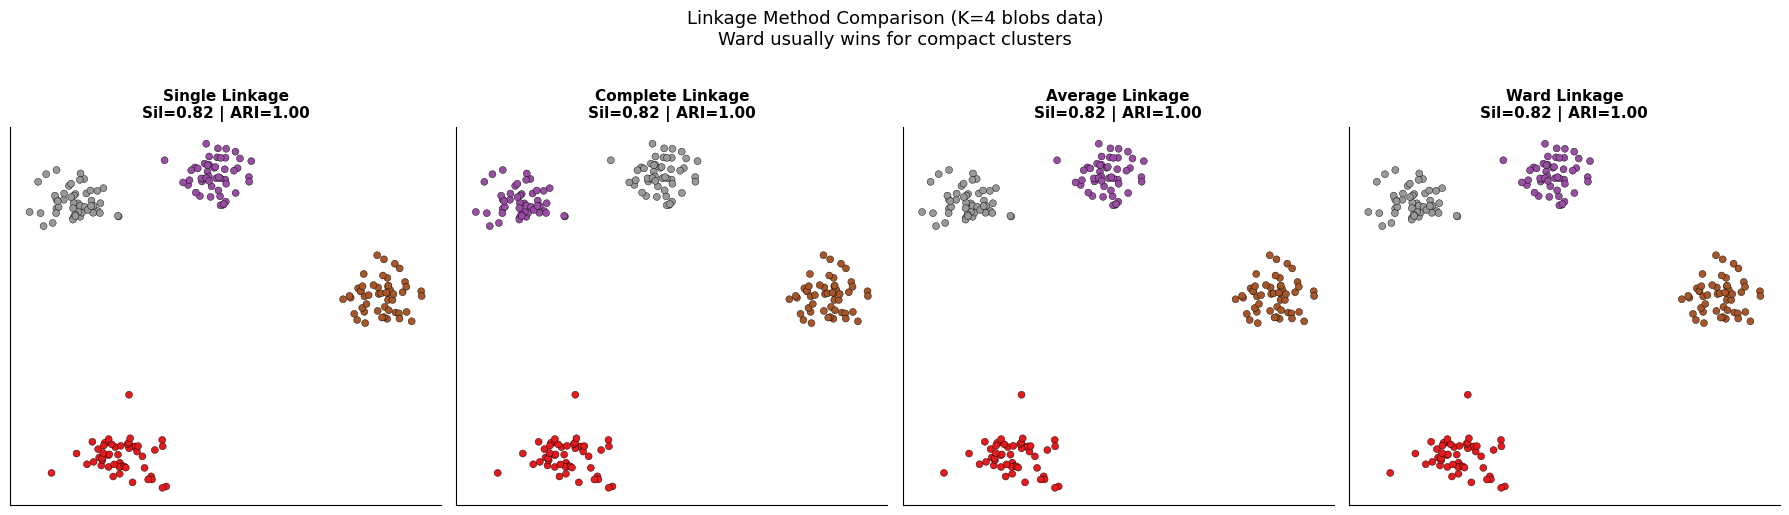

In [ ]:
# Compare all 4 linkage methods
X_link, y_link = make_blobs(n_samples=200, centers=4, cluster_std=0.9, random_state=42)

linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_link)
    sil = silhouette_score(X_link, labels)
    ari = adjusted_rand_score(y_link, labels)

    ax.scatter(X_link[:, 0], X_link[:, 1], c=labels, cmap='Set1',
               s=25, edgecolors='k', linewidths=0.3)
    ax.set_title(f'{method.capitalize()} Linkage\nSil={sil:.2f} | ARI={ari:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Linkage Method Comparison (K=4 blobs data)\nWard usually wins for compact clusters',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


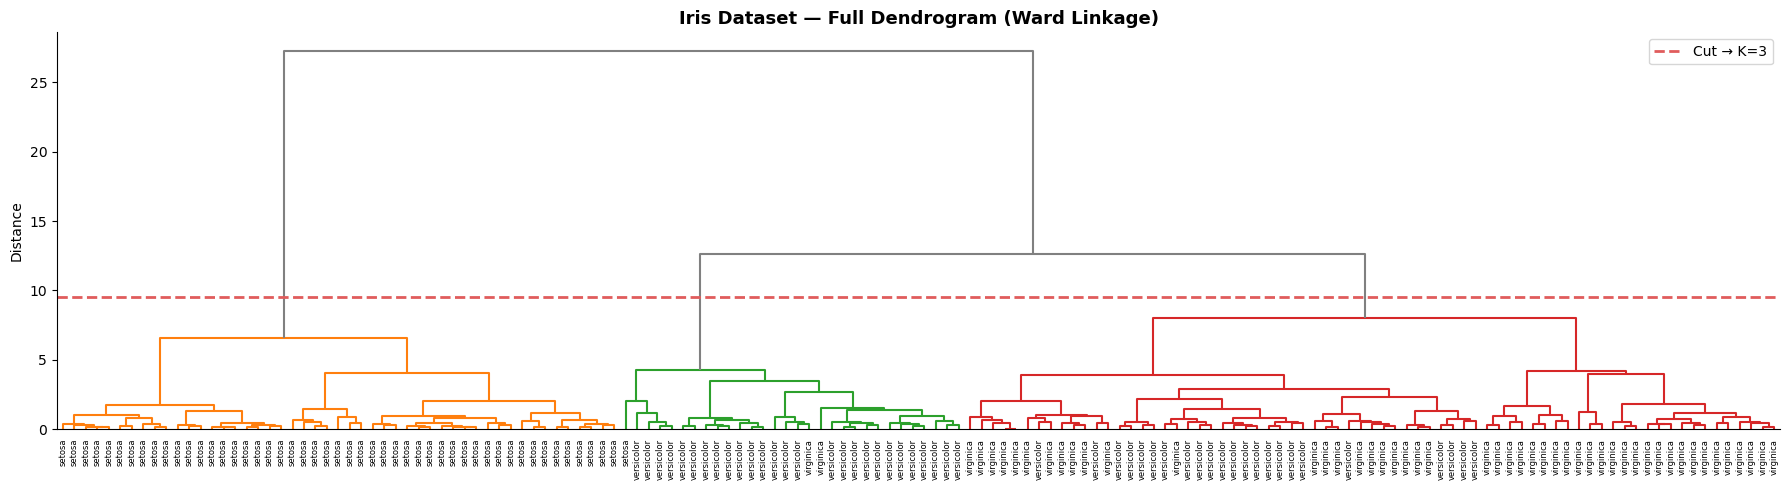

Hierarchical (Ward) on Iris:
  Silhouette Score: 0.4467
  Adjusted Rand Index (vs true labels): 0.6153


In [ ]:
# Hierarchical on real data — Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Full dendrogram
Z_iris = linkage(X_iris_scaled, method='ward')

fig, ax = plt.subplots(figsize=(18, 5))
dendrogram(Z_iris, ax=ax, labels=iris.target_names[y_iris],
           leaf_font_size=6,
           above_threshold_color='gray',
           color_threshold=0.35 * max(Z_iris[:, 2]))
ax.axhline(y=0.35 * max(Z_iris[:, 2]), color='#E05C5C', linestyle='--', linewidth=2,
           label='Cut → K=3')
ax.set_title('Iris Dataset — Full Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

# Cluster quality
labels_iris = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_iris_scaled)
print(f'Hierarchical (Ward) on Iris:')
print(f'  Silhouette Score: {silhouette_score(X_iris_scaled, labels_iris):.4f}')
print(f'  Adjusted Rand Index (vs true labels): {adjusted_rand_score(y_iris, labels_iris):.4f}')


---
## 4. DBSCAN — Density-Based Spatial Clustering

**Two parameters:**
- **eps (ε)** — radius to search for neighbors around each point
- **minPts** — minimum neighbors within ε to be a 'core' point

**Three point types:**

| Type | Condition | Role |
|------|-----------|------|
| Core | Has ≥ minPts neighbors within eps | Heart of a cluster |
| Border | Within eps of a core, but < minPts neighbors itself | Edge of cluster |
| Noise | Not reachable from any core point | Outlier — labeled **−1** |

**Key advantage:** No need to specify K. Outliers are automatically labeled.


In [ ]:
# Visualize Core / Border / Noise point types
np.random.seed(42)
X_demo = np.array([
    [1,1],[1.3,1.2],[0.8,1.4],[1.1,0.8],[0.9,1.1],  # dense cluster 1
    [4,4],[4.2,4.3],[3.8,4.1],[4.1,3.9],[4.3,4.2],  # dense cluster 2
    [2.5,2.5],                                         # border point
    [6,1], [0,5]                                       # noise
])

eps_val = 0.7
minpts  = 4

# Classify points manually
def classify_points(X, eps, minpts):
    from scipy.spatial.distance import cdist
    D = cdist(X, X)
    neighbors = [(D[i] < eps).sum() - 1 for i in range(len(X))]
    core_mask   = np.array(neighbors) >= minpts
    border_mask = np.zeros(len(X), dtype=bool)
    noise_mask  = np.ones(len(X), dtype=bool)
    for i in range(len(X)):
        if core_mask[i]:
            noise_mask[i] = False
        else:
            for j in range(len(X)):
                if core_mask[j] and D[i,j] < eps:
                    border_mask[i] = True
                    noise_mask[i]  = False
                    break
    return core_mask, border_mask, noise_mask

core_m, border_m, noise_m = classify_points(X_demo, eps_val, minpts)

fig, ax = plt.subplots(figsize=(9, 7))

# Draw eps circles around core points
for i, pt in enumerate(X_demo):
    if core_m[i]:
        circle = plt.Circle(pt, eps_val, fill=True, color='#0D8E8E', alpha=0.08)
        circle_edge = plt.Circle(pt, eps_val, fill=False, color='#0D8E8E', alpha=0.4, linestyle='--', linewidth=1)
        ax.add_patch(circle)
        ax.add_patch(circle_edge)

# Plot points
ax.scatter(X_demo[core_m,   0], X_demo[core_m,   1], s=180, color='#0D8E8E',
           edgecolors='k', linewidths=1.5, zorder=5, label=f'Core (≥{minpts} neighbors in eps)')
ax.scatter(X_demo[border_m, 0], X_demo[border_m, 1], s=150, color='#F0A500',
           edgecolors='k', linewidths=1.5, zorder=5, label='Border (within eps of core)')
ax.scatter(X_demo[noise_m,  0], X_demo[noise_m,  1], s=150, color='#E05C5C',
           marker='X', edgecolors='k', linewidths=1.5, zorder=5, label='Noise / Outlier')

# Labels
labels_text = ['C','C','C','C','C','C','C','C','C','C','B','N','N']
for (x,y), lbl in zip(X_demo, labels_text):
    ax.annotate(lbl, (x,y), ha='center', va='center', fontsize=9,
                fontweight='bold', color='white', zorder=6)

ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 6.5)
ax.legend(fontsize=10, loc='upper right')
ax.set_title(f'DBSCAN Point Types (eps={eps_val}, minPts={minpts})\nShaded circles = eps radius around core points',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# DBSCAN on different shapes — where it shines
datasets_db = [
    (make_moons(n_samples=300, noise=0.08, random_state=42),   'Moons',   0.15, 5),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42), 'Circles', 0.15, 5),
]

# Noisy blobs
X_nb, y_nb = make_blobs(n_samples=200, centers=3, cluster_std=0.6, random_state=42)
noise_pts = np.random.uniform(-7, 7, (30, 2))
X_nb = np.vstack([X_nb, noise_pts])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ((X_d, _), name, eps_d, min_d) in zip(axes[:2], datasets_db):
    db = DBSCAN(eps=eps_d, min_samples=min_d)
    labels = db.fit_predict(X_d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    ax.scatter(X_d[:, 0], X_d[:, 1], c=labels, cmap='tab10',
               s=30, edgecolors='k', linewidths=0.3)
    ax.set_title(f'DBSCAN on {name}\nClusters found: {n_clusters}  |  Noise: {n_noise}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

# Noisy blobs
db3 = DBSCAN(eps=0.8, min_samples=5)
labels3 = db3.fit_predict(X_nb)
n_clusters3 = len(set(labels3)) - (1 if -1 in labels3 else 0)
n_noise3    = (labels3 == -1).sum()

colors_nb = ['#E05C5C' if l == -1 else plt.cm.tab10(l / 3) for l in labels3]
axes[2].scatter(X_nb[:, 0], X_nb[:, 1], c=colors_nb, s=30, edgecolors='k', linewidths=0.3)
axes[2].set_title(f'DBSCAN on Noisy Blobs\nClusters found: {n_clusters3}  |  Noise: {n_noise3} (red)',
                   fontsize=11, fontweight='bold')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle('DBSCAN Handles Non-Spherical Shapes & Detects Outliers Automatically',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# DBSCAN parameter sensitivity — eps and minPts
X_param, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.7, random_state=42)

eps_vals  = [0.3, 0.7, 1.5]
min_vals  = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(13, 12))

for i, eps in enumerate(eps_vals):
    for j, minp in enumerate(min_vals):
        db = DBSCAN(eps=eps, min_samples=minp)
        labels = db.fit_predict(X_param)
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        ax = axes[i][j]
        ax.scatter(X_param[:, 0], X_param[:, 1], c=labels, cmap='tab10',
                   s=20, edgecolors='k', linewidths=0.2)
        ax.set_title(f'eps={eps}, minPts={minp}\n{n_clust} clusters, {n_noise} noise',
                     fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('DBSCAN Parameter Sensitivity\nToo small eps → too many clusters / noise | Too large → everything merges',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print('Rule of thumb: use k-distance plot (next cell) to choose eps')


In [ ]:
# K-distance plot — systematic way to choose eps
from sklearn.neighbors import NearestNeighbors

X_kd, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.7, random_state=42)
minPts = 5

nbrs = NearestNeighbors(n_neighbors=minPts).fit(X_kd)
distances, _ = nbrs.kneighbors(X_kd)
k_distances = np.sort(distances[:, -1])[::-1]  # distance to k-th neighbor

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='#0D8E8E', linewidth=2)
plt.axhline(y=0.7, color='#E05C5C', linestyle='--', linewidth=2, label='Suggested eps ≈ 0.7')
plt.xlabel('Points sorted by distance to k-th neighbor', fontsize=12)
plt.ylabel(f'Distance to {minPts}-th neighbor', fontsize=12)
plt.title(f'K-Distance Plot (k={minPts})\n→ Choose eps at the "elbow" of this curve', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('The elbow in this curve = good eps value')
print('Same idea as the elbow method for K-Means!')


---
## 5. Head-to-Head: All Three Algorithms


In [ ]:
# All three on all four dataset shapes
datasets_all = [
    (make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),   'Blobs',   3, 0.4, 5),
    (make_moons(n_samples=300, noise=0.08, random_state=42),                   'Moons',   2, 0.15, 5),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),     'Circles', 2, 0.15, 5),
]

algo_names = ['K-Means', 'Hierarchical\n(Ward)', 'DBSCAN']
fig, axes = plt.subplots(3, 3, figsize=(14, 13))

for col, ((X_d, y_true), dname, k, eps, minp) in enumerate(datasets_all):
    # K-Means
    l1 = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_d)
    # Hierarchical
    l2 = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_d)
    # DBSCAN
    l3 = DBSCAN(eps=eps, min_samples=minp).fit_predict(X_d)

    for row, (labels, algo) in enumerate(zip([l1, l2, l3], algo_names)):
        ax = axes[row][col]
        ari = adjusted_rand_score(y_true, labels)
        n_noise = (labels == -1).sum()
        ax.scatter(X_d[:, 0], X_d[:, 1], c=labels, cmap='tab10',
                   s=20, edgecolors='k', linewidths=0.2)
        title = f'{algo} on {dname}\nARI={ari:.2f}'
        if n_noise > 0:
            title += f' | Noise={n_noise}'
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Algorithm Comparison on Different Data Shapes\n(ARI=1.0 = perfect match with true labels)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Final summary — metrics on Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()
X_ir = StandardScaler().fit_transform(iris.data)
y_ir = iris.target

models_c = {
    'K-Means (K=3)':            KMeans(n_clusters=3, random_state=42, n_init=10),
    'Hierarchical Ward (K=3)':  AgglomerativeClustering(n_clusters=3, linkage='ward'),
    'DBSCAN (eps=0.5, min=5)':  DBSCAN(eps=0.5, min_samples=5),
}

print('='*70)
print(f'{"Algorithm":<30} {"Silhouette":>12} {"ARI":>10} {"Clusters":>10} {"Noise":>8}')
print('='*70)

for name, model in models_c.items():
    labels = model.fit_predict(X_ir)
    valid = labels != -1
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    sil = silhouette_score(X_ir[valid], labels[valid]) if valid.sum() > 1 else 0
    ari = adjusted_rand_score(y_ir, labels)
    print(f'{name:<30} {sil:>12.4f} {ari:>10.4f} {n_clust:>10} {n_noise:>8}')

print('='*70)
print()
print('Silhouette Score: closer to 1.0 = better separated clusters')
print('ARI: 1.0 = perfect match with true labels | 0.0 = random')


---
## Summary — Cheat Sheet

```
K-MEANS:
  WCSS = Σ Σ ||xᵢ − μₖ||²          minimize within-cluster variance
  Assign: label = argmin ||x − μₖ||   nearest centroid
  Update: μₖ = mean(all points in Cₖ)
  Choose K: elbow method (WCSS) or silhouette score

HIERARCHICAL:
  Start: each point = 1 cluster
  Merge: 2 closest clusters each step (linkage defines 'closest')
  Linkage: single / complete / average / ward
  Cut: dendrogram at desired height → K clusters
  Best default: Ward linkage

DBSCAN:
  Parameters: eps (radius), minPts (density threshold)
  Core:   N(xᵢ, eps) ≥ minPts → starts a cluster
  Border: within eps of a core, but N(x, eps) < minPts
  Noise:  not reachable from any core → label = -1
  Choose eps: k-distance plot (elbow)
```

| | K-Means | Hierarchical | DBSCAN |
|--|---------|--------------|--------|
| Specify K? | Yes | No | No |
| Cluster shape | Spherical | Any | Any |
| Handles outliers? | No | Somewhat | Yes |
| Speed | Fast | Slow O(n²) | Moderate |
| Best for | Large data, known K | Exploration, small data | Noisy data, unknown K |
